# Tag 08 - Experten
## Hierarchical Clustering & Gap Statistic

In [1]:
OUTPUT_SUBDIR = "Experte"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data"
OUT_DIR = PROJECT_DIR / "output" / OUTPUT_SUBDIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR)

PROJECT_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\customer-segmentation-rfm-kmeans
DATA_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\customer-segmentation-rfm-kmeans\data
OUT_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\customer-segmentation-rfm-kmeans\output\Experte


In [3]:
possible_files = [
    "Online Retail.xlsx", "Online_Retail.xlsx", "online_retail.xlsx",
    "Online Retail.csv", "Online_Retail.csv", "online_retail.csv"
]
DATA_PATH = next((DATA_DIR / f for f in possible_files if (DATA_DIR / f).exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f"Put Online Retail data in {DATA_DIR}. Accepted names: {possible_files}")

if DATA_PATH.suffix.lower() in [".xlsx", ".xls"]:
    retail = pd.read_excel(DATA_PATH)
else:
    retail = pd.read_csv(DATA_PATH, encoding="latin1")

retail.columns = retail.columns.astype(str).str.strip()

retail = retail.rename(columns={
    "Customer ID": "CustomerID",
    "CustomerID": "CustomerID",
    "Invoice": "InvoiceNo",
    "InvoiceNo": "InvoiceNo",
    "Invoice Date": "InvoiceDate",
    "InvoiceDate": "InvoiceDate",
    "Price": "UnitPrice",
    "UnitPrice": "UnitPrice"
})

print("Using file:", DATA_PATH.name)
print("Shape:", retail.shape)
print("Columns:", retail.columns.tolist())
retail.head()

required_cols = ["CustomerID", "InvoiceNo", "InvoiceDate", "Quantity", "UnitPrice"]
missing = [c for c in required_cols if c not in retail.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}\nAvailable columns: {list(retail.columns)}")

retail = retail.dropna(subset=required_cols).copy()
retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"], errors="coerce")
retail["Quantity"] = pd.to_numeric(retail["Quantity"], errors="coerce")
retail["UnitPrice"] = pd.to_numeric(retail["UnitPrice"], errors="coerce")
retail = retail.dropna(subset=["InvoiceDate", "Quantity", "UnitPrice"])
retail = retail[(retail["Quantity"] > 0) & (retail["UnitPrice"] > 0)].copy()
retail["TotalPrice"] = retail["Quantity"] * retail["UnitPrice"]
retail["CustomerID"] = retail["CustomerID"].astype(str)

snapshot_date = retail["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = retail.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()
rfm = rfm[(rfm["Frequency"] > 0) & (rfm["Monetary"] > 0)].copy()

features = ["Recency", "Frequency", "Monetary"]
X = rfm[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("RFM shape:", rfm.shape)
rfm.head()


Using file: Online_Retail.csv
Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [4]:
rng = np.random.default_rng(42)
max_rows = min(2000, X_scaled.shape[0])
sample_idx = rng.choice(X_scaled.shape[0], size=max_rows, replace=False)

X_work = X_scaled[sample_idx].copy()
rfm_work = rfm.iloc[sample_idx].reset_index(drop=True)

print(X_work.shape)

(2000, 3)


In [5]:
rng = np.random.default_rng(42)

rng = np.random.default_rng(42)
X_rfm = X_scaled

max_rows = min(2000, X_rfm.shape[0])

sample_idx = rng.choice(
    X_rfm.shape[0],
    size=max_rows,
    replace=False
)

if hasattr(X_rfm, "iloc"):
    X_work = X_rfm.iloc[sample_idx].copy()
else:
    X_work = X_rfm[sample_idx]

rfm_work = rfm.iloc[sample_idx].reset_index(drop=True)

print(X_work.shape)

sample_idx = rng.choice(
    X_rfm.shape[0],
    size=max_rows,
    replace=False
)

if hasattr(X_rfm, "iloc"):
    X_work = X_rfm.iloc[sample_idx].copy()
else:
    X_work = X_rfm[sample_idx]

rfm_work = rfm.iloc[sample_idx].reset_index(drop=True)

print(X_work.shape)

(2000, 3)
(2000, 3)


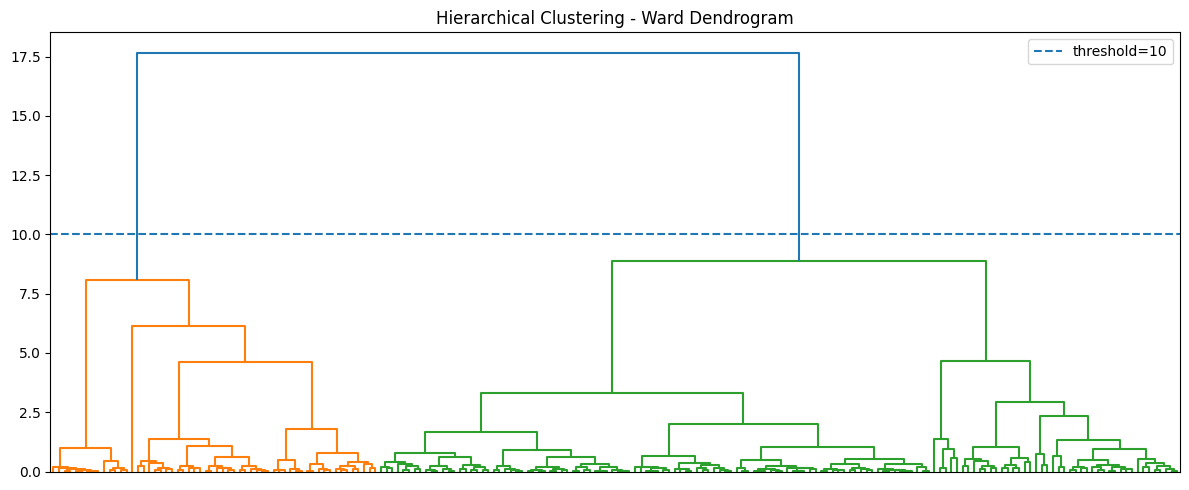

In [6]:
X_dendro = X_work[:min(200, X_work.shape[0])]
Z = linkage(X_dendro, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True)
plt.axhline(y=10, linestyle="--", label="threshold=10")
plt.title("Hierarchical Clustering - Ward Dendrogram")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "expert_01_dendrogram_ward.png", dpi=160)
plt.show()

In [7]:
def gap_statistic(X, k_range=range(1, 9), B=10, random_state=42):
    rng = np.random.default_rng(random_state)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=5).fit(X)
        log_wk = np.log(km.inertia_)
        ref_logs = []
        for b in range(B):
            X_ref = rng.uniform(mins, maxs, size=X.shape)
            ref_km = KMeans(n_clusters=k, random_state=random_state + b, n_init=3).fit(X_ref)
            ref_logs.append(np.log(ref_km.inertia_))
        ref_logs = np.array(ref_logs)
        gap = ref_logs.mean() - log_wk
        sk = ref_logs.std(ddof=1) * np.sqrt(1 + 1 / B)
        rows.append({"k": k, "gap": gap, "sk": sk, "log_wk": log_wk})
    return pd.DataFrame(rows)

GAP_RESULTS = gap_statistic(X_work, range(1, 9), B=10, random_state=42)
GAP_RESULTS.to_csv(OUT_DIR / "expert_gap_statistic_results.csv", index=False)
GAP_RESULTS

C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Das System kann die angegebene Datei nicht finden
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\esmae\.conda\envs\py311\Li

,k,gap,sk,log_wk
0,1,3.594953,0.012951,8.849933
1,2,3.545466,0.014053,8.374753
2,3,3.626959,0.015714,7.879256
3,4,3.469504,0.019186,7.609293
4,5,3.558722,0.009976,7.339808
5,6,3.589465,0.014091,7.141366
6,7,3.625614,0.012117,6.954395
7,8,3.654968,0.011609,6.779204


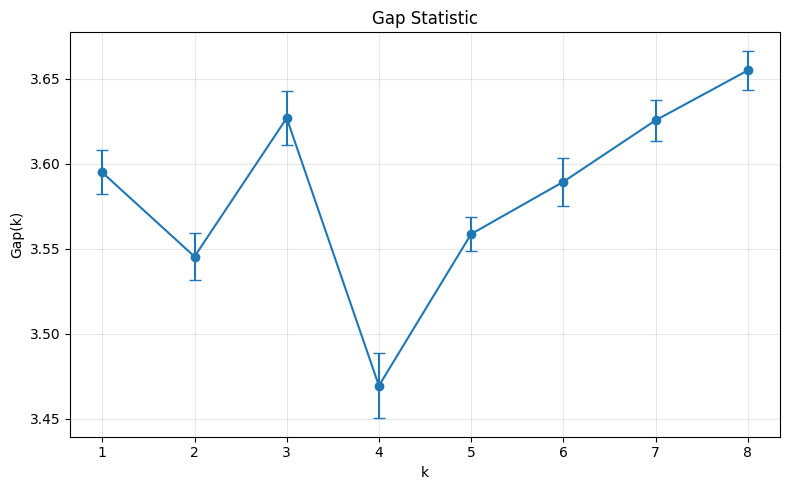

In [8]:
plt.figure(figsize=(8, 5))
plt.errorbar(GAP_RESULTS["k"], GAP_RESULTS["gap"], yerr=GAP_RESULTS["sk"], marker="o", capsize=4)
plt.xlabel("k")
plt.ylabel("Gap(k)")
plt.title("Gap Statistic")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "expert_02_gap_statistic.png", dpi=160)
plt.show()

In [9]:
def safe_scores(X, labels):
    labels = np.asarray(labels)
    mask = labels != -1
    unique = set(labels[mask])
    if len(unique) < 2 or mask.sum() <= len(unique):
        return np.nan, np.nan, np.nan
    return (
        silhouette_score(X[mask], labels[mask]),
        davies_bouldin_score(X[mask], labels[mask]),
        calinski_harabasz_score(X[mask], labels[mask])
    )

k_gap = int(GAP_RESULTS.sort_values("gap", ascending=False).iloc[0]["k"])
k_compare = max(2, k_gap)

labels_kmeans = KMeans(n_clusters=k_compare, random_state=42, n_init=10).fit_predict(X_work)
labels_hier = AgglomerativeClustering(n_clusters=k_compare, linkage="ward").fit_predict(X_work)
labels_dbscan = DBSCAN(eps=1.0, min_samples=5).fit_predict(X_work)

rows = []
for name, labels in [
    (f"K-Means k={k_compare}", labels_kmeans),
    (f"Hierarchical Ward k={k_compare}", labels_hier),
    ("DBSCAN eps=1.0 min_samples=5", labels_dbscan)
]:
    sil, db, ch = safe_scores(X_work, labels)
    rows.append({
        "method": name,
        "n_clusters": len(set(labels)) - (1 if -1 in labels else 0),
        "n_noise": int((labels == -1).sum()),
        "silhouette_higher_better": sil,
        "davies_bouldin_lower_better": db,
        "calinski_harabasz_higher_better": ch
    })

COMPARISON = pd.DataFrame(rows)
COMPARISON.to_csv(OUT_DIR / "expert_clustering_model_comparison.csv", index=False)
COMPARISON

,method,n_clusters,n_noise,silhouette_higher_better,davies_bouldin_lower_better,calinski_harabasz_higher_better
0,K-Means k=8,8,0,0.499183,0.661747,1972.272605
1,Hierarchical Ward k=8,8,0,0.500988,0.608770,1808.342028
2,DBSCAN eps=1.0 min_samples=5,1,20,NaN,NaN,NaN


In [10]:
rfm_out = rfm_work.copy()
rfm_out["kmeans_label"] = labels_kmeans
rfm_out["hierarchical_label"] = labels_hier
rfm_out["dbscan_label"] = labels_dbscan
rfm_out.to_csv(OUT_DIR / "expert_rfm_sample_with_cluster_labels.csv", index=False)
rfm_out.head()

,CustomerID,Recency,Frequency,Monetary,kmeans_label,hierarchical_label,dbscan_label
0,12945.0,288,1,462.95,3,3,0
1,18048.0,203,2,172.29,1,6,0
2,17506.0,76,1,302.20,5,0,0
3,17673.0,2,6,1629.12,5,0,0
4,14764.0,47,1,278.30,5,0,0
